In [12]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cvxpy as cp
from dotenv import load_dotenv
from tiingo import TiingoClient
from fredapi import Fred
from tabulate import tabulate

load_dotenv()

# --- Universe ---
TICKERS = ['SPY', 'PLTR', 'NVDA', 'INTC', 'GLD', 'EEM']
ASSETS  = ['PLTR', 'NVDA', 'INTC', 'GLD', 'EEM']  # portfolio universe (excludes benchmark)
FREQ = '1hour'

# --- Date windows ---
FETCH_START = '2020-10-01'   # PLTR IPO'd 2020-09-30; gives a clean Nov-2020 start
FETCH_END   = '2026-04-30'

    # Witholding the training and testing windows for now
#TRAIN_START = '2020-11-01'
#TRAIN_END   = '2025-04-30'
#HOLD_START  = '2025-05-01'
#HOLD_END    = '2026-04-30'

# --- Local paths ---
DATA_DIR        = 'data'
RAW_CACHE       = f'{DATA_DIR}/intraday_1hr_raw.parquet'
CLEANED_CACHE = f'{DATA_DIR}/intraday_1hr_cleaned.parquet'

os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
# === Reading data from Tiingo / Cache ===


if os.path.exists(RAW_CACHE):
    print(f"Loading raw cache: {RAW_CACHE}")
    raw = pd.read_parquet(RAW_CACHE)
else:
    print("Fetching data from Tiingo...")
    client = TiingoClient({'api_key': os.getenv('TIINGO_API_KEY')})

    dataframes = []

    for ticker in TICKERS:
        print(f"Fetching {ticker}...")

        df = client.get_dataframe(
            ticker, 
            startDate=FETCH_START, 
            endDate=FETCH_END, 
            frequency=FREQ,
            columns='open,high,low,close,volume')
            #afterHours=True, --- Not available on the standard endpoint; requires requests
            #forceFill=False)
        
        df['ticker'] = ticker
        df = df.reset_index(names='datetime')

        dataframes.append(df)

    raw = pd.concat(dataframes, ignore_index=True)

# raw.to_parquet(RAW_CACHE, index=False) --- Skipping cache write because the data is already cached; uncomment if you want to refresh the cache

Loading raw cache: data/intraday_1hr_raw.parquet


In [4]:
# === Initial Summary Stats for Data Validation ===

print(raw['datetime'].min(), raw['datetime'].max())

print(raw.head())
print(raw.info())
raw.describe()

2020-10-01 14:00:00+00:00 2026-04-30 19:00:00+00:00
                   datetime     open     high      low    close    volume  \
0 2020-10-01 14:00:00+00:00  336.605  337.435  335.560  336.680  113013.0   
1 2020-10-01 15:00:00+00:00  336.680  337.675  335.790  337.210   64050.0   
2 2020-10-01 16:00:00+00:00  337.195  337.420  336.235  337.145   74792.0   
3 2020-10-01 17:00:00+00:00  337.160  337.690  335.865  336.245   37771.0   
4 2020-10-01 18:00:00+00:00  336.245  337.195  334.995  336.955  141272.0   

  ticker  
0    SPY  
1    SPY  
2    SPY  
3    SPY  
4    SPY  
<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   datetime  52416 non-null  datetime64[us, UTC]
 1   open      52416 non-null  float64            
 2   high      52416 non-null  float64            
 3   low       52416 non-null  float64            
 4   close     5

,open,high,low,close,volume
count,52416.000000,52416.000000,52416.000000,52416.000000,5.241600e+04
mean,194.141589,194.731059,193.513842,194.147731,1.305197e+05
std,200.327988,200.893029,199.718058,200.337231,1.598597e+05
min,5.975000,6.015000,5.950000,5.975000,0.000000e+00
25%,39.705000,39.775000,39.638750,39.710000,3.509325e+04
50%,135.040000,135.662500,134.287500,135.037500,8.526850e+04
75%,307.120000,307.536250,306.492500,307.120000,1.652110e+05
max,1218.140000,1224.500000,1216.050000,1224.500000,4.477359e+06


In [5]:
# === Wide Pivoting; 1 asset per column ===

close_wide = raw.pivot(index='datetime', columns='ticker', values='close')
returns_wide = np.log(close_wide).diff()

In [13]:
# --- Summary Stats for Prices and Returns ---

print(tabulate(returns_wide.describe(), headers='keys', tablefmt='pipe', floatfmt='.4f'))

|       |       EEM |       GLD |      INTC |      NVDA |      PLTR |       SPY |
|:------|----------:|----------:|----------:|----------:|----------:|----------:|
| count | 8735.0000 | 8735.0000 | 8735.0000 | 8735.0000 | 8735.0000 | 8735.0000 |
| mean  |    0.0000 |    0.0001 |    0.0001 |   -0.0001 |    0.0003 |    0.0001 |
| std   |    0.0048 |    0.0044 |    0.0124 |    0.0314 |    0.0172 |    0.0042 |
| min   |   -0.0685 |   -0.0658 |   -0.3317 |   -2.2952 |   -0.2332 |   -0.0445 |
| 25%   |   -0.0011 |   -0.0009 |   -0.0036 |   -0.0038 |   -0.0055 |   -0.0013 |
| 50%   |    0.0000 |    0.0000 |    0.0000 |    0.0000 |    0.0000 |    0.0000 |
| 75%   |    0.0013 |    0.0011 |    0.0036 |    0.0044 |    0.0056 |    0.0015 |
| max   |    0.0571 |    0.0588 |    0.2288 |    0.2230 |    0.2315 |    0.0650 |


Price Summary:
ticker          EEM          GLD         INTC         NVDA         PLTR  \
count   8736.000000  8736.000000  8736.000000  8736.000000  8736.000000   
mean      45.818538   223.172513    38.476074   318.035163    48.793680   
std        6.633546    80.293192    12.872857   222.499424    55.312197   
min       33.795000   151.230000    18.180000    93.930000     5.975000   
25%       39.993750   170.163750    28.131250   158.212500    13.580000   
50%       43.915000   182.192500    36.875000   208.635000    23.040000   
75%       51.331250   246.052500    48.435000   469.148750    68.055000   
max       63.965000   495.680000    94.950000  1224.500000   207.345000   

ticker          SPY  
count   8736.000000  
mean     490.590422  
std      100.793967  
min      323.245000  
25%      411.343750  
50%      452.200000  
75%      571.777500  
max      718.605000  
---------------------

Returns Summary:
ticker          EEM          GLD         INTC         NVDA         PLTR

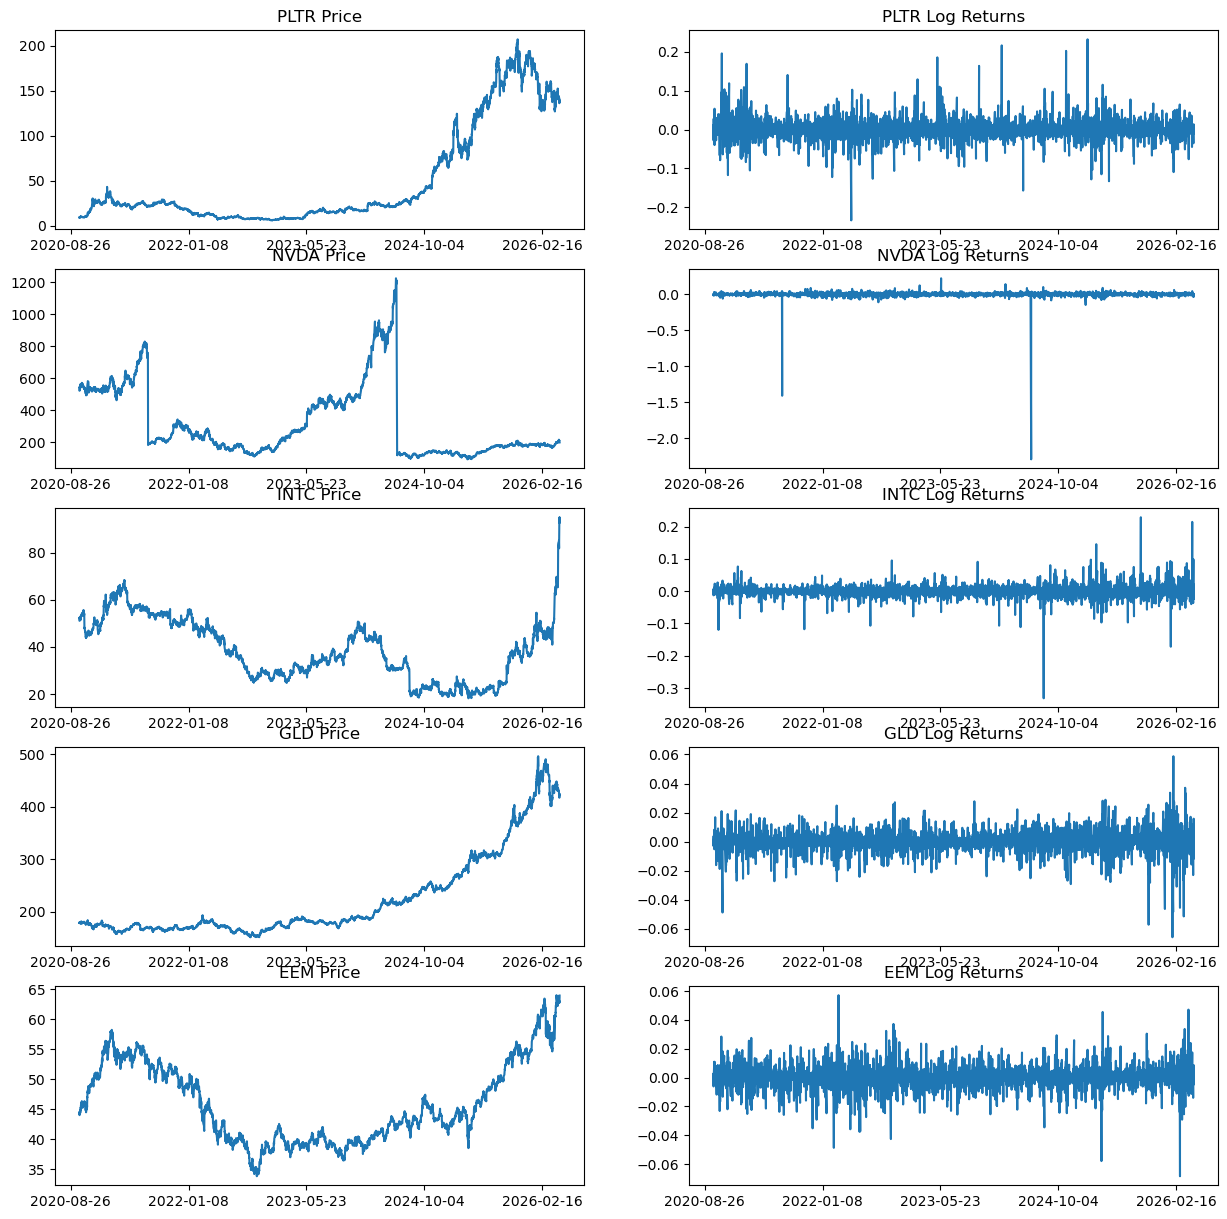

In [ ]:
# === Plotting Prices and Returns by Asset ===

fig, axes = plt.subplots(len(ASSETS), 2, figsize=(15, 3 * len(ASSETS)))
for i, asset in enumerate(ASSETS):
    axes[i, 0].plot(close_wide.index, close_wide[asset])
    axes[i, 0].set_title(f'{asset} Price')
    axes[i, 0].xaxis.set_major_locator(mticker.MaxNLocator(5))
    
    axes[i, 1].plot(returns_wide.index, returns_wide[asset])
    axes[i, 1].set_title(f'{asset} Log Returns')
    axes[i, 1].xaxis.set_major_locator(mticker.MaxNLocator(5))

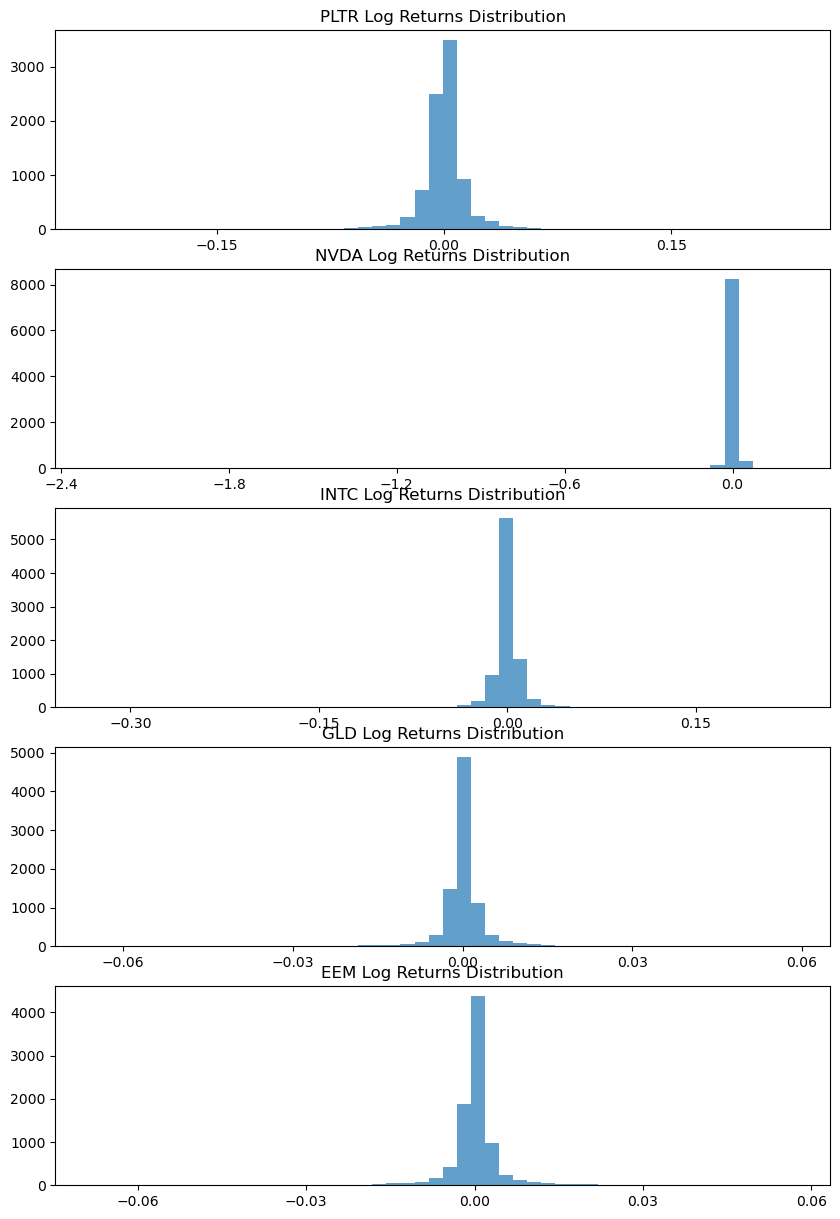

In [ ]:
# === Histograms of Returns ===

fig, axes = plt.subplots(len(ASSETS), 1, figsize=(10, 3 * len(ASSETS)))
for i, asset in enumerate(ASSETS):
    axes[i].hist(returns_wide[asset].dropna(), bins=50, alpha=0.7)
    axes[i].set_title(f'{asset} Log Returns Distribution')
    axes[i].xaxis.set_major_locator(mticker.MaxNLocator(5))